### Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import json
from typing import Dict, List, Tuple, Optional

In [3]:
import sys
sys.path.append("..")

from scripts.eda import basic_summary, plot_series, plot_distribution, plot_rolling_statistics, plot_acf_series, plot_pacf_series, plot_hourly_mean, plot_dayofweek_mean, plot_boxplot_by_hour, plot_boxplot_by_dayofweek, adf_test, compute_anomaly_statistics, plot_lag, fast_fourier_transform_estimation

### Data Analysis Pipeline

The identified files will be loaded below, and each will undergo a basic time series analysis, along with some relevant plotting. This file will conclude with a brief discussion of observations and potential modeling constraints.

Files to load:
- **CPU_UTIL_1** - ec2_cpu_utilization_5f5533.csv
- **CPU_UTIL_2** - ec2_cpu_utilization_53ea38.csv
- **DISK_WRITE_1** - ec2_disk_write_bytes_c0d644.csv
- **DISK_WRITE_2** - ec2_disk_write_bytes_1ef3de.csv
- **NETWORK_IN_1** - ec2_network_in_5abac7.csv
- **NETWORK_IN_2** - ec2_network_in_257a54.csv
- **REQUEST_COUNT** - elb_request_count_8c0756.csv

Note that in all cases, the data is structured with time-stamps and a singular value, meaning that this is not a **multi-variate time-series analysis**.

In [4]:
files_map = {
    'CPU_UTIL_1': 'ec2_cpu_utilization_5f5533.csv',
    'CPU_UTIL_2': 'ec2_cpu_utilization_53ea38.csv',
    'DISK_WRITE_': 'ec2_disk_write_bytes_c0d644.csv',
    'DISK_WRITE_2': 'ec2_disk_write_bytes_1ef3de.csv',
    'NETWORK_IN_1': 'ec2_network_in_5abac7.csv',
    'NETWORK_IN_2': 'ec2_network_in_257a54.csv',
    'REQUEST_COUNT': 'elb_request_count_8c0756.csv'
}

DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), 'data')

In [5]:
with open(os.path.join(DATA_DIR, 'combined_windows.json')) as file:
    windows_data = json.load(file)

anomaly_windows_map: Dict = {
    key: [
        (pd.Timestamp(start), pd.Timestamp(end))
        for start, end in windows_data.get(f'realAWSCloudwatch/{file}', [])
    ]
    for key, file in files_map.items()
}

dfs_map: Dict[str, Tuple[pd.DataFrame, List[Tuple[pd.Timestamp, pd.Timestamp]]]] = {}

for key, file in files_map.items():
    df = pd.read_csv(os.path.join(DATA_DIR, files_map[key]))
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp').reset_index(drop=True)
    dfs_map[key] = (df, anomaly_windows_map[key])

In [6]:
# Invokes visualization methods defined earlier for a comprehensive understanding of the dataset.
def summarize(dataset_name: str, df: pd.DataFrame, anomaly_windows: List[Tuple[pd.Timestamp, pd.Timestamp]]):
    basic_summary(df, True)
    plot_series(df, anomaly_windows, f'Time Series Plot (With Anomalies) for {dataset_name}')
    plot_distribution(df)
    plot_rolling_statistics(df, 24, f'Rolling Statistics (Window = 24 hours) Plot for {dataset_name}')
    plot_rolling_statistics(df, 48, f'Rolling Statistics (Window = 48 hours) Plot for {dataset_name}')
    plot_acf_series(df, 100, f'ACF Plot for {dataset_name}')
    plot_pacf_series(df, 50, f'PACF Plot for {dataset_name}')
    plot_hourly_mean(df, f'Average Hourly Value for {dataset_name}')
    plot_dayofweek_mean(df, f'Average Value by Day for {dataset_name}')
    plot_boxplot_by_hour(df, f'Hourly Box-Plot for {dataset_name}')
    plot_boxplot_by_dayofweek(df, f'Day-of-Week Box-Plot for {dataset_name}')
    adf_test(df, 'value', True)
    compute_anomaly_statistics(df, anomaly_windows, 'timestamp', True)
    plot_lag(df, anomaly_windows, [1, 3, 6, 12, 36, 72], 'value', 'timestamp')
    fast_fourier_transform_estimation(df, 'value', 'timestamp', None, True)

Metric                  Value
----------------------  ---------------------------------------
n_rows                  4032
start_time              2014-02-14 14:27:00
end_time                2014-02-28 14:22:00
median_interval         0 days 00:05:00
mode_interval           0   0 days 00:05:00
                        Name: timestamp, dtype: timedelta64[us]
n_missing_timestamps    0
n_duplicate_timestamps  0
min_value               34.766
max_value               68.092
mean_value              43.11037160218254
std_value               4.303564641024769


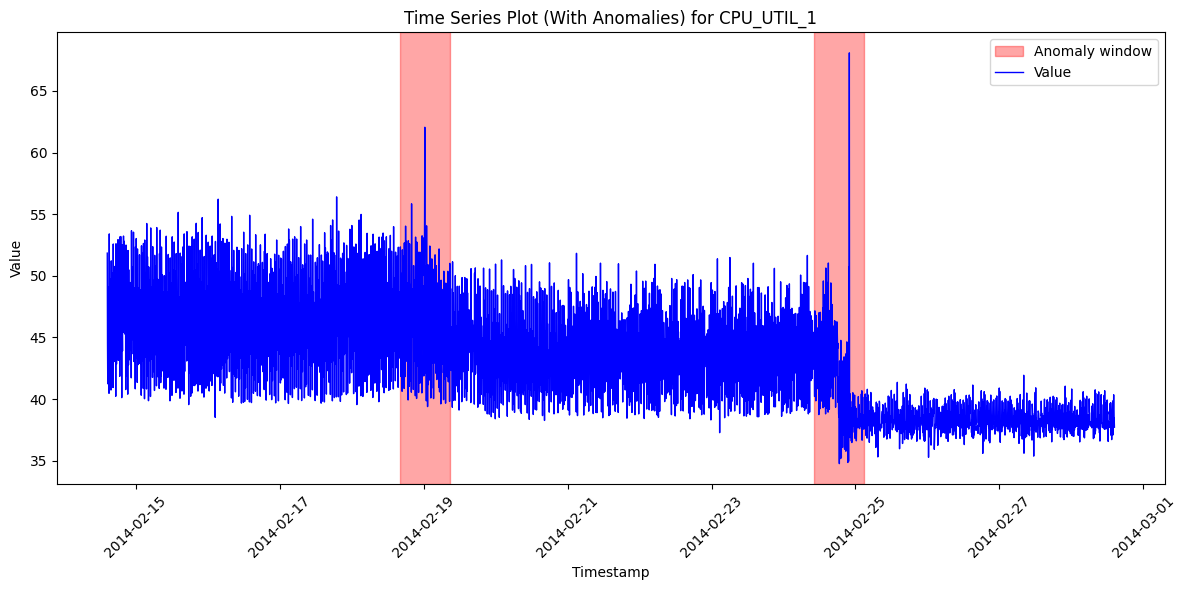

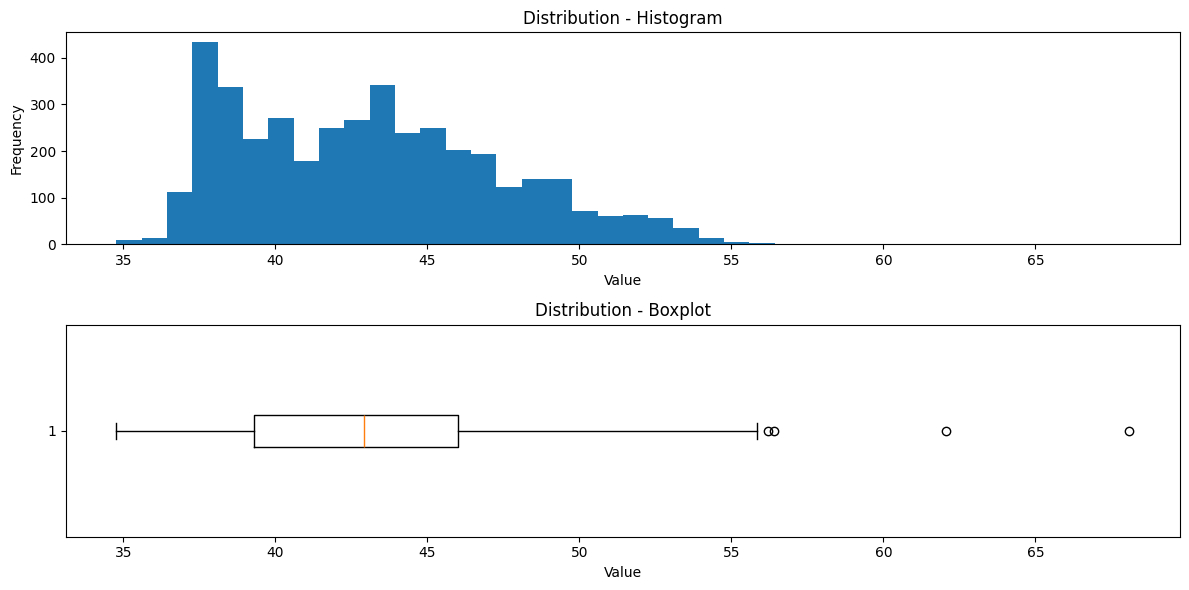

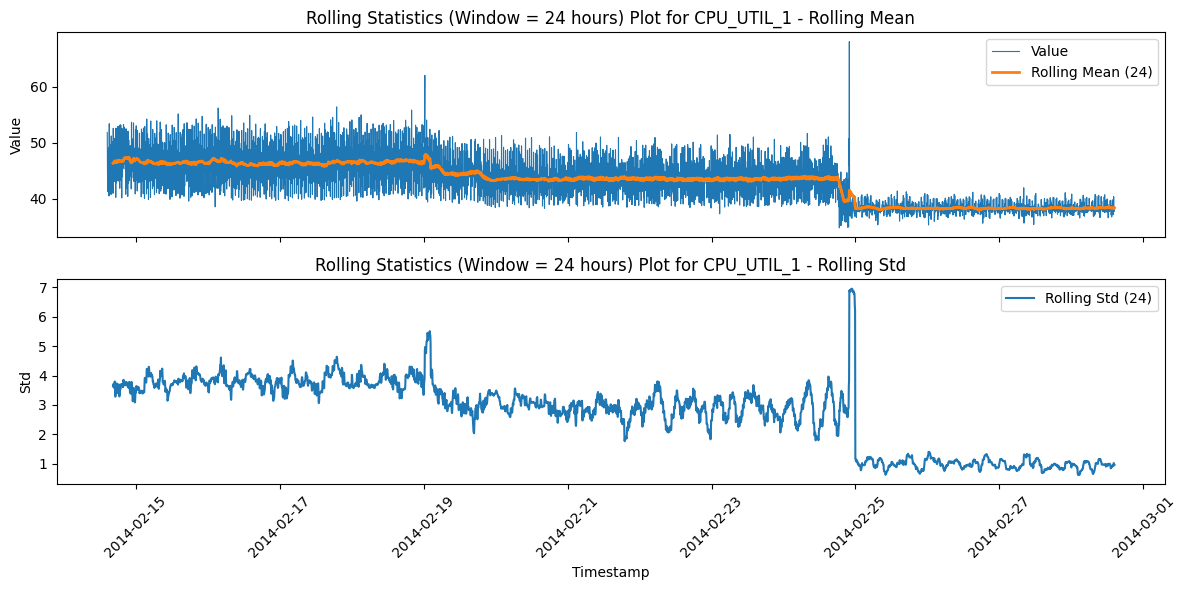

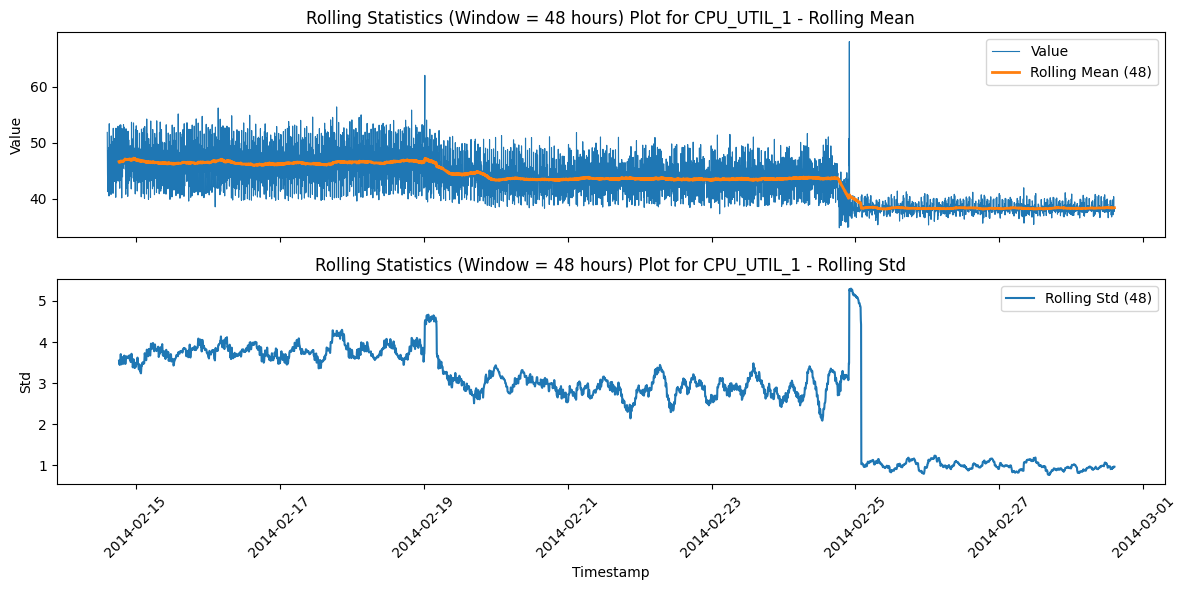

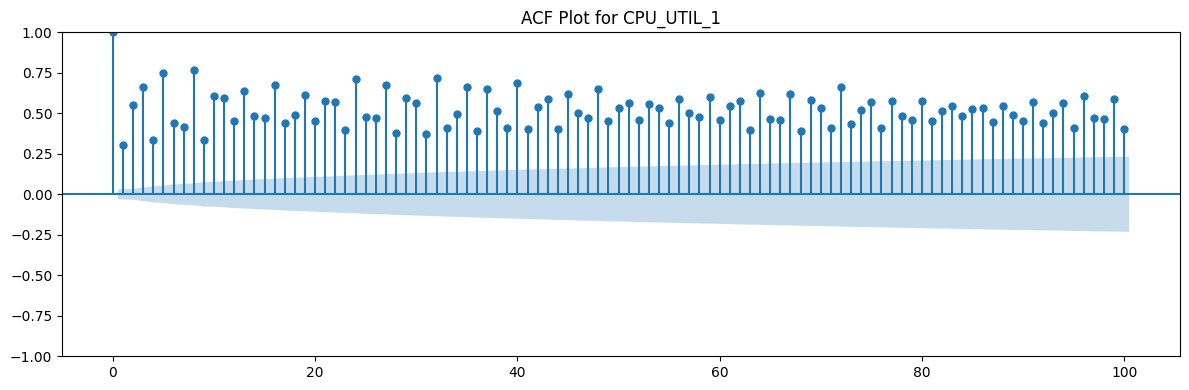

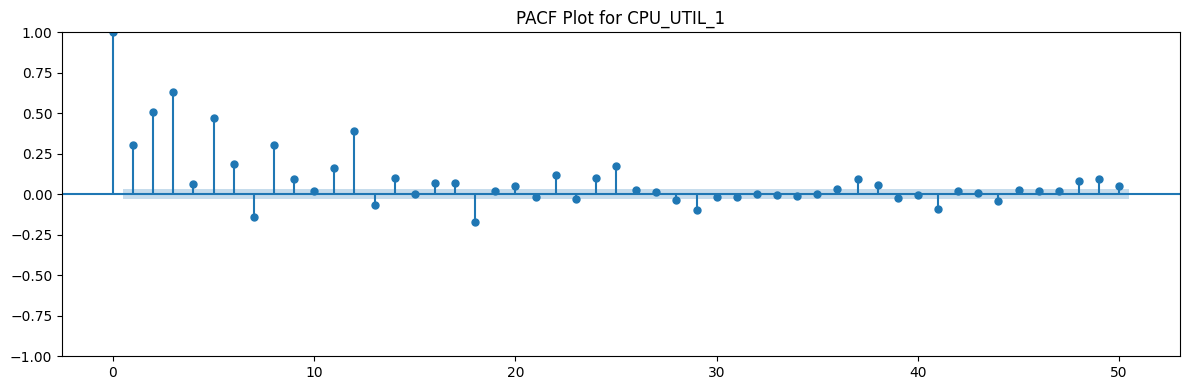

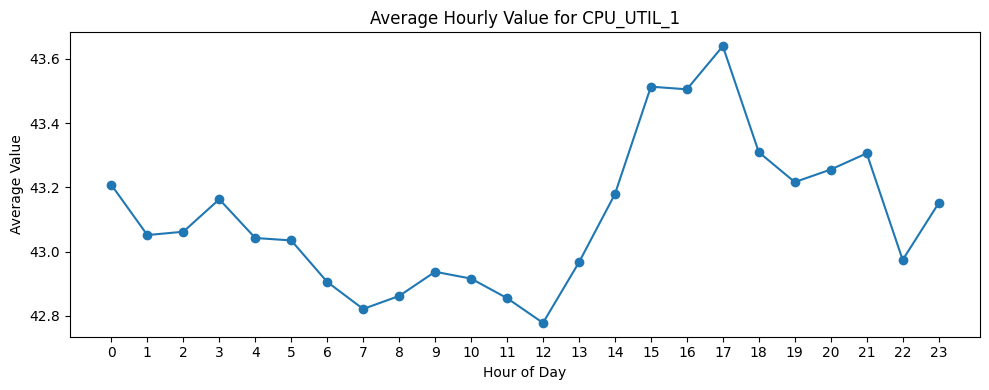

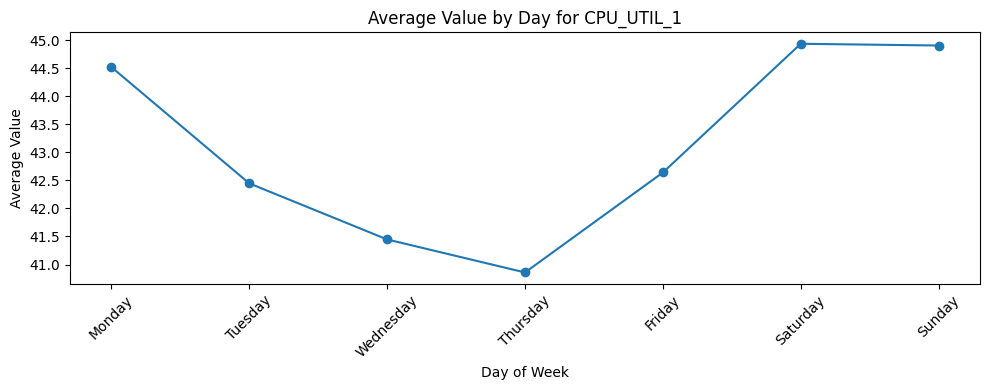

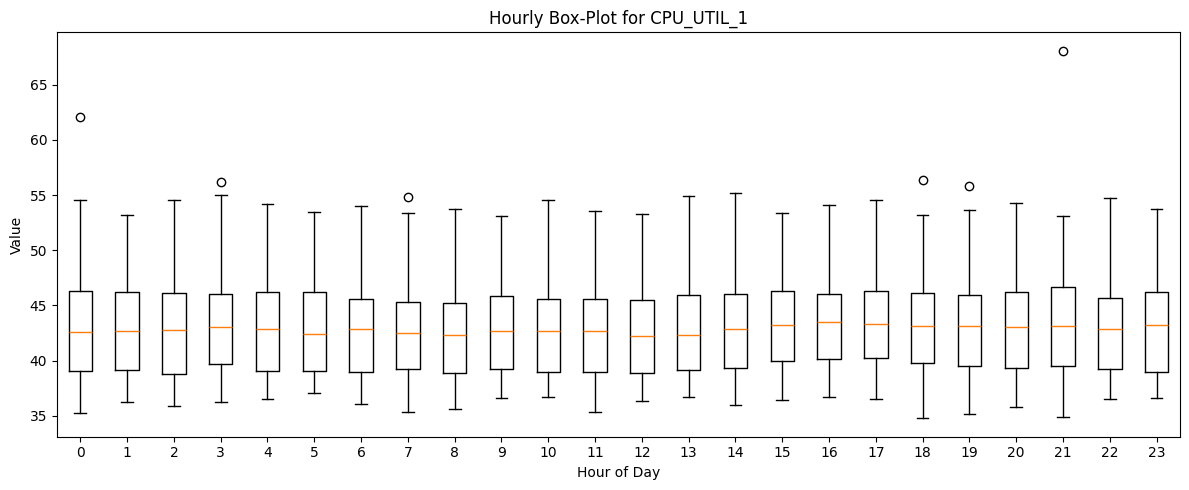

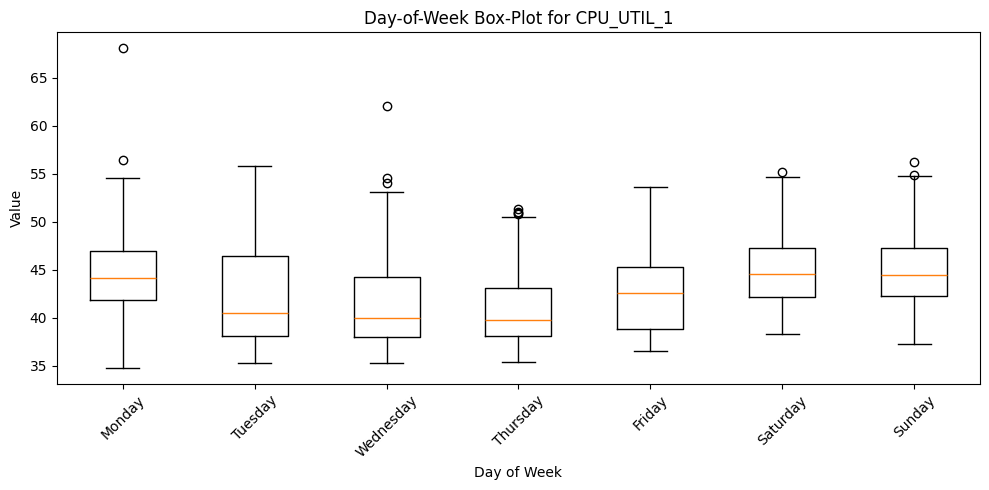

Property                         Value
-------------------------  -----------
adf_statistic                -0.733508
adf_p_value                   0.837878
adf_used_lag                 28
adf_n_obs                  4003
adf_critical_value_1pct      -3.43198
adf_critical_value_5pct      -2.86226
adf_critical_value_10pct     -2.56715
adf_is_stationary_at_5pct     0
Property                  Value
------------------------  -------------------
n_anomaly_windows         2
total_anomaly_duration    1 days 09:20:00
avg_anomaly_duration      0 days 16:40:00
n_points                  4032
n_anomalous_points        402
anomalous_point_fraction  0.09970238095238096


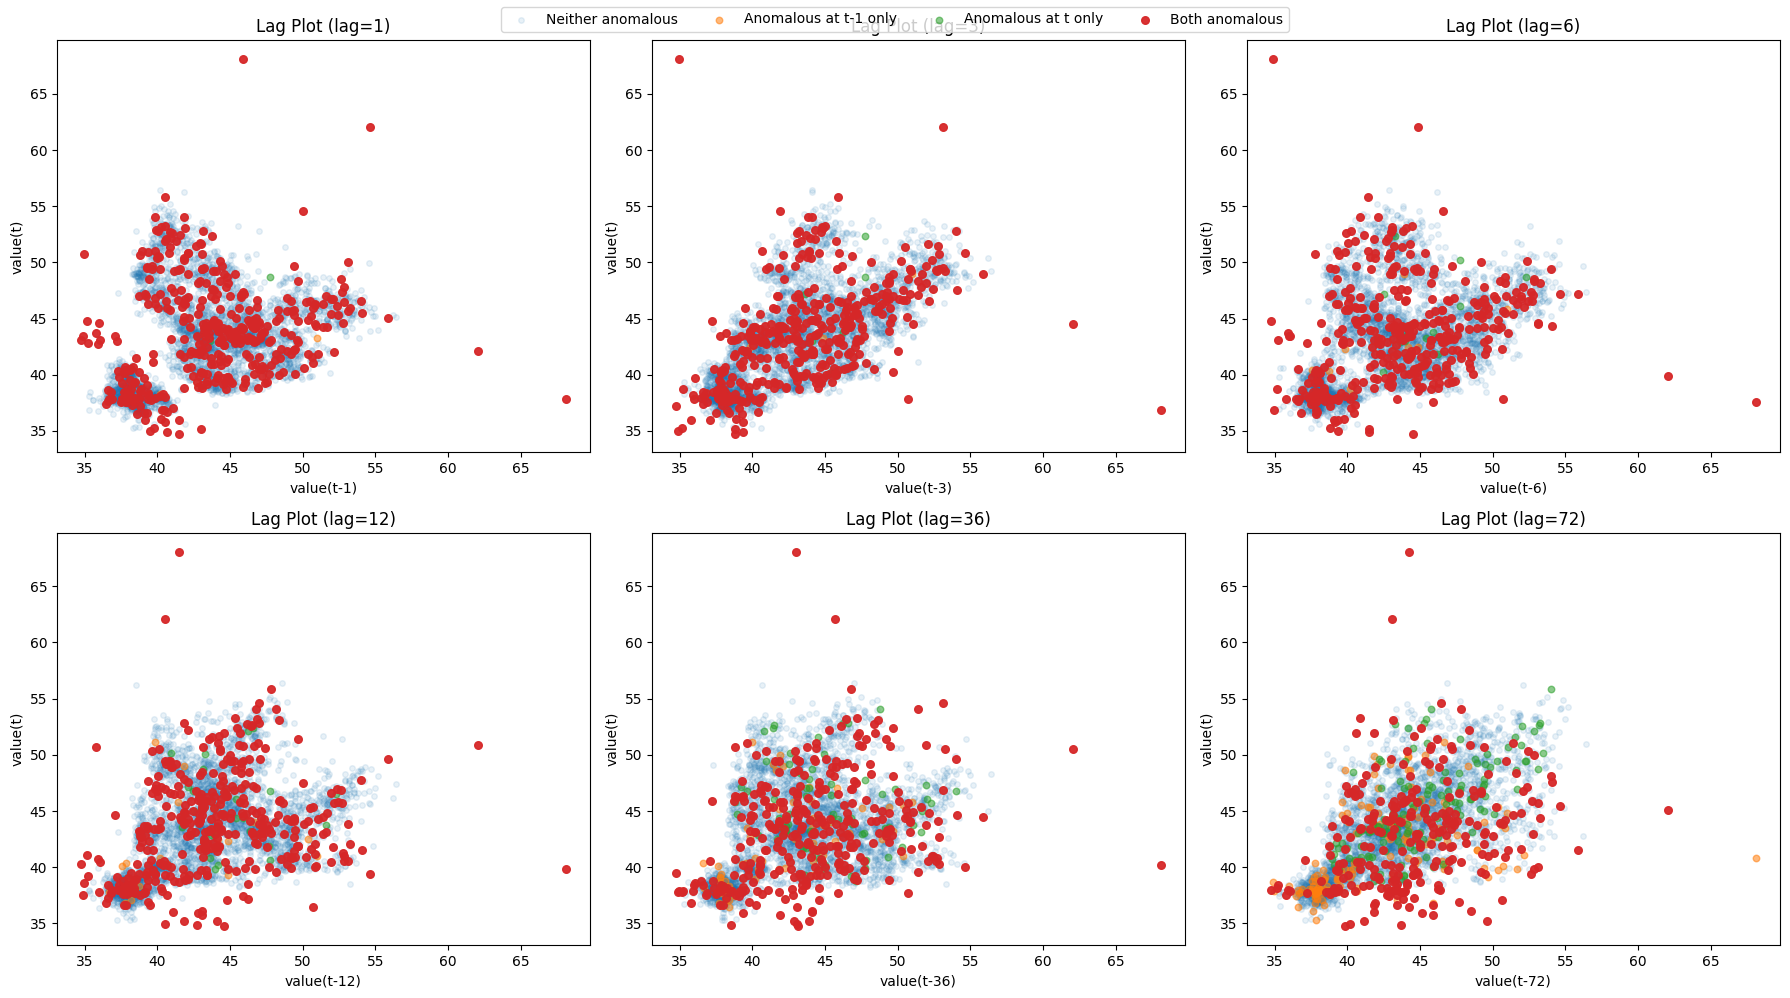

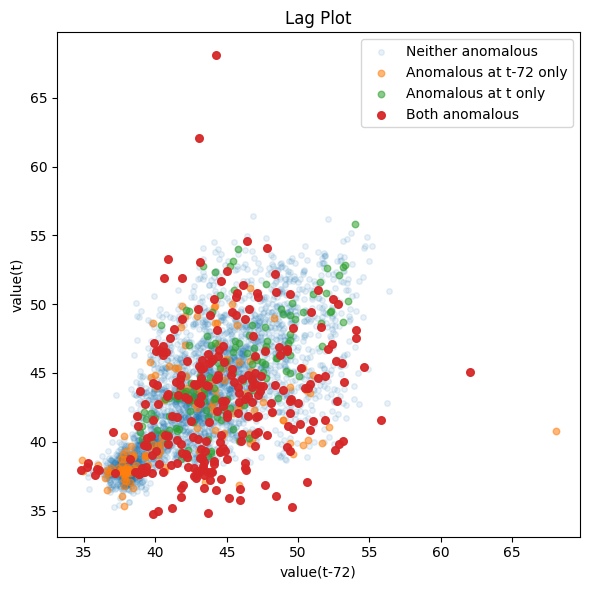

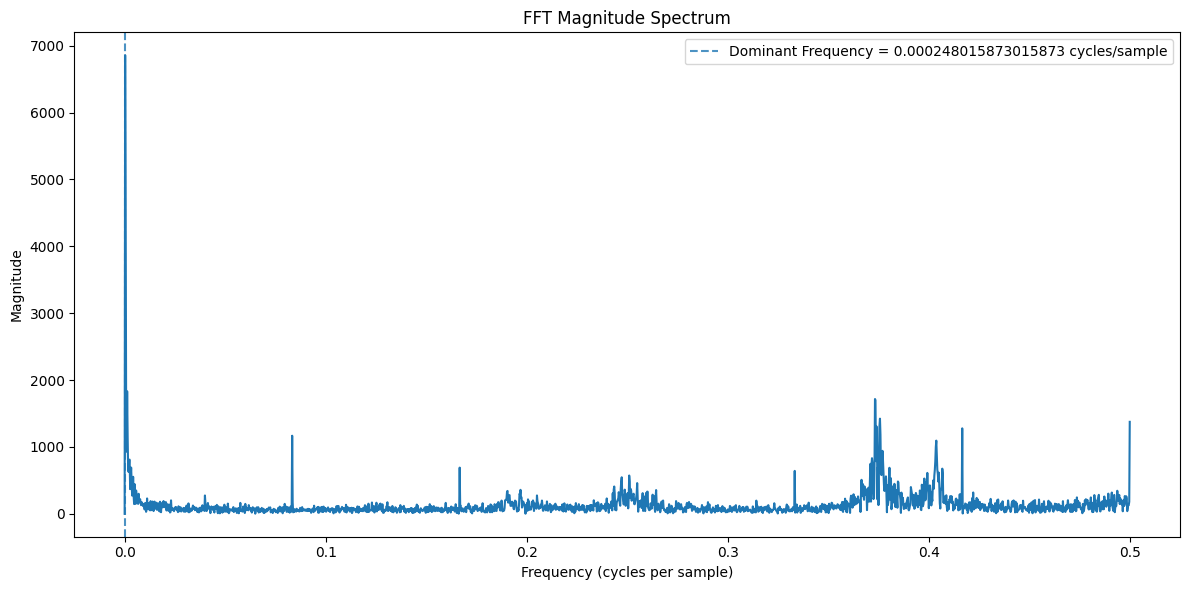

Property                       Value
-----------------------------  --------------------
dominant_frequency_per_sample  0.000248015873015873
dominant_period_in_samples     4032.0
dominant_period_timedelta      14 days 00:00:00
sampling_interval              0 days 00:05:00
n_used_points                  4032


In [10]:
dataframe, anomaly_windows = dfs_map['CPU_UTIL_1']

summarize('CPU_UTIL_1', dataframe, anomaly_windows)